# 5.3b Dolphin on NISAR GSLCs over Mexico City

*EarthScope 2026 ISCE+ course - Scott Staniewicz*

Here we run on a stack of NISAR data from early NISAR data

This notebook is an example of how quality metrics behave differently on a short stack. We will see a large known subsidence signal in Mexico city, and explore how `dolphin`'s temporal coherence show very high values due to the small stack size.

In [1]:
%pip install --upgrade "dolphin @ git+https://github.com/scottstanie/dolphin.git@develop-scott"

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/scottstanie/dolphin.git (to revision develop-scott) to /tmp/pip-install-zujimo2u/dolphin_5b86d0b9f13a4f6db1654391a1b048dd
  Running command git clone --filter=blob:none --quiet https://github.com/scottstanie/dolphin.git /tmp/pip-install-zujimo2u/dolphin_5b86d0b9f13a4f6db1654391a1b048dd
  Running command git checkout -b develop-scott --track origin/develop-scott
  Switched to a new branch 'develop-scott'
  branch 'develop-scott' set up to track 'origin/develop-scott'.
  Resolved https://github.com/scottstanie/dolphin.git to commit c9f6c10ceac11703e655c9628d91aac848387aaa
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from opera_utils.nisar import search
from opera_utils.nisar._download import run_download

HERE = Path.cwd()

## Finding a stack

`opera_utils.nisar.search` queries CMR. The two arguments that define a repeat-pass stack are `relative_orbit_number` (the track) and `track_frame_number`.

In [3]:
products = search(
    relative_orbit_number=113,
    orbit_direction="D",
    track_frame_number=79,
    short_name="NISAR_L2_GSLC_BETA_V1",
)
print(f"{len(products)} granules")
for p in sorted(str(x.filename).split("/")[-1] for x in products):
    print("  ", p)

8 granules
   NISAR_L2_PR_GSLC_003_113_D_079_4005_DHDH_A_20251025T011329_20251025T011404_X05009_N_F_J_001.h5
   NISAR_L2_PR_GSLC_004_113_D_079_4005_DHDH_A_20251106T011330_20251106T011404_X05009_N_F_J_001.h5
   NISAR_L2_PR_GSLC_005_113_D_079_4005_DHDH_A_20251118T011330_20251118T011405_X05009_N_F_J_001.h5
   NISAR_L2_PR_GSLC_006_113_D_079_4005_DHDH_A_20251130T011331_20251130T011405_X05010_F_F_J_001.h5
   NISAR_L2_PR_GSLC_007_113_D_079_4005_DHDH_A_20251212T011331_20251212T011406_X05009_N_F_J_001.h5
   NISAR_L2_PR_GSLC_008_113_D_079_4005_DHDH_A_20251224T011332_20251224T011406_X05009_N_F_J_001.h5
   NISAR_L2_PR_GSLC_009_113_D_079_4005_DHDH_A_20260105T011332_20260105T011407_X05009_N_F_J_001.h5
   NISAR_L2_PR_GSLC_010_113_D_079_4005_DHDH_A_20260117T011333_20260117T011407_X05010_N_F_J_001.h5


Over this frame there are 8 beta acquisitions (2025-10 to 2026-01) and 4 provisional ones (2026-06 to 07). We will use the Beta frames due to the longer time period.

### Download and subset on the fly

A full NISAR GSLC granule is 22–25 GB.
`run_download` issues HTTP range requests and pulls only the rows and columns covering your bounding box straight out of the remote HDF5.

| box | GSLC pixels | per date | dolphin output at 4x strides |
|---|---|---|---|
| 15 x 15 km | 3000 x 3000 | 43 MB | 750 x 750 |
| 25 x 25 km (below) | 5000 x 5000 | ~120 MB | 1250 x 1250 |
| 58 x 60 km (whole basin) | 11,928 x 11,590 | 687 MB | 2982 x 2897 |


The AOI is centred on the Tlahuac–Chalco corridor in the southeast of the basin, the fastest-subsiding ground in the valley, and reaches far enough up the surrounding slopes to give the time series a reference point that is not itself moving.

In [4]:
import os, requests

# NISAR lives in its own bucket with its own credentials endpoint.
# opera-utils does not know about it yet (opera-adt/opera-utils#203), so fetch
# the temporary creds directly and hand them over via the environment, which
# `get_s3_fs` checks first.
r = requests.get(
  "https://nisar.asf.earthdatacloud.nasa.gov/s3credentials",
  allow_redirects=True,
)  # uses ~/.netrc for urs.earthdata.nasa.gov
r.raise_for_status()
c = r.json()
os.environ["AWS_ACCESS_KEY_ID"] = c["accessKeyId"]
os.environ["AWS_SECRET_ACCESS_KEY"] = c["secretAccessKey"]
os.environ["AWS_SESSION_TOKEN"] = c["sessionToken"]


In [5]:
BBOX = (-99.0889, 19.1371, -98.8511, 19.3629)  # W, S, E, N — 25 x 25 km
SLC_DIR = HERE / "mx_gslc"

# Only HH is needed: interferometry requires the same channel at every epoch.
#
# `num_workers=1` is deliberate. Each worker holds its whole subset in memory
# before writing, so on a large AOI the default of 4 parallel workers is enough
# to get one killed (`BrokenProcessPool`). At this box size 4 is safe, but
# serial costs little and always works.
slc_paths = run_download(
    bbox=BBOX,
    relative_orbit_number=113,
    orbit_direction="D",
    track_frame_number=79,
    short_name="NISAR_L2_GSLC_BETA_V1",
    polarizations=["HH"],
    output_dir=SLC_DIR,
    url_type="s3",
    num_workers=4,
)
print(
    f"{len(slc_paths)} files, "
    f"{sum(p.stat().st_size for p in slc_paths) / 1e9:.2f} GB"
)

  0%|          | 0/8 [00:00<?, ?it/s]

8 files, 1.00 GB


1 minute download to make a (small) stack!

### Configuring Dolphin to use the GSLCs

Since the GSLC is already coregistered (since it is geocoded onto the same grid), dolphin can stack these directly.
The only extra info needed is which "subdataset" within the HDF5 file holds the data.
Here we use `/science/LSAR/GSLC/grids/frequencyA/HH` (but you could point to `frequencyB`, or `HV`).

In [6]:
SUBDATASET = "/science/LSAR/GSLC/grids/frequencyA/HH"

with h5py.File(sorted(SLC_DIR.glob("*.h5"))[0]) as hf:
    grid = hf["science/LSAR/GSLC/grids/frequencyA"]
    print(f"shape       {grid['HH'].shape}  {grid['HH'].dtype}")
    print(
        f"pixel size  {float(grid['xCoordinateSpacing'][()])} m x "
        f"{abs(float(grid['yCoordinateSpacing'][()]))} m"
    )
    print(f"range BW    {float(grid['rangeBandwidth'][()]) / 1e6:.0f} MHz")
    print(f"EPSG        {int(grid['projection'][()])}")

shape       (4996, 4999)  complex64
pixel size  5.0 m x 5.0 m
range BW    40 MHz
EPSG        32614


Dolphin can downsample the output with `strides`, which speeds it up linearly with the number of strides (that is, it skips processing the pixels that will not appear in the output)

| GSLC posting | bandwidth | `--sy --sx` | `half_window` (y, x) |
|---|---|---|---|
| 5 m x 5 m | 40 MHz | `4 4` | 7, 7 |
| 5 m x 10 m | 20 MHz | `4 2` | 7, 5 |

Both give ~20 m output pixels and a similar ground-area SHP window.

## Set up processing configuration with `dolphin config`


In [7]:
import os
import site
import shutil

user_bin = os.path.join(site.USER_BASE, "bin")
os.environ["PATH"] = user_bin + os.pathsep + os.environ.get("PATH", "")

print("Added to PATH:", user_bin)
print("dolphin:", shutil.which("dolphin"))

Added to PATH: /home/jovyan/.local/bin
dolphin: /home/jovyan/.local/bin/dolphin


In [8]:
# `--outfile` will not create its parent, so make the work directory first.
!mkdir -p mx_dolphin
!dolphin config \
    --slc-files mx_gslc/*.h5 \
    --subdataset /science/LSAR/GSLC/grids/frequencyA/HH \
    --sy 4 --sx 4 \
    --ps-options.amp-dispersion-threshold 0.05 \
    --phase-linking.half-window.y 7 --phase-linking.half-window.x 7 \
    --phase-linking.write-closure-phase \
    --phase-linking.nearest-n-coherence 1 \
    --unwrap-options.unwrap-method WHIRLWIND \
    --work-directory mx_dolphin \
    --outfile mx_dolphin/dolphin_config.yaml

Saving configuration to mx_dolphin/dolphin_config.yaml


The flags worth knowing:

- `--subdataset`: which array inside the HDF5 holds the complex data.
- `--sy 4 --sx 4`: output strides. Phase linking averages over neighborhoods, so writing every pixel is wasted effort; this gives 20 m output.
- `--ps-options.amp-dispersion-threshold 0.05`: the amplitude dispersion (std dev / mean) threshold, below which we label pixels as a PS pixel. This is also strongly affected by the small stack. With few SLCs, many more pixels will be called "PS" for a given threshold. Default is 0.2, so we drop this way down here.
- `--phase-linking.half-window`: the SHP search radius, in input (full-res) pixels.
- `--phase-linking.write-closure-phase`: Since we form the full covariance matrix, we can see what the "closure phase" is between adjacent dates. This is a topic of ongoing reserarch, but in short, where there is high closure phase, you should trust displacment results less.
- `--phase-linking.nearest-n-coherence 1 `: Write out the typical multi-looked interferogram coherence between the nearest-neighbor interferograms. This is normally not saved for phase linking, but since it's a by product, it can be written out for use in applications like change detection of damage proxy mapping
- `--unwrap-options.unwrap-method WHIRLWIND`: [whirlwind](https://github.com/scottstanie/whirlwind-insar), a new unwrapper, gives similar results to snaphu (in early testing), takes ~10% of the time

In [9]:
!dolphin run mx_dolphin/dolphin_config.yaml

[WARNING|displacement|L116] 2026-08-05T23:27:11+0000: Unable to parse OPERA bursts (Could not parse burst id from /home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_gslc/NISAR_L2_PR_GSLC_003_113_D_079_4005_DHDH_A_20251025T011329_20251025T011404_X05009_N_F_J_001.h5), falling back to non-OPERA mode
[INFO|displacement|L240] 2026-08-05T23:27:11+0000: Found SLC files from 1 bursts/blocks
[INFO|wrapped_phase|L117] 2026-08-05T23:27:11+0000: Running wrapped phase estimation in /home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/phase_linking
[INFO|wrapped_phase|L164] 2026-08-05T23:27:12+0000: Creating persistent scatterer file /home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/phase_linking/PS/ps_pixels.tif
[INFO|_readers|L1169] 2026-08-05T23:27:13+0000: Processing (512, 512) sized blocks...
PS (/home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/phase
[INFO|_amp_dispersion|L202] 2026-08-05T23:27:25+0000: Waiting to write 0 bloc

## Inspecting outputs

### Temporal coherence

fraction of pixels with temporal coherence > 0.50: 0.990
fraction of pixels with temporal coherence > 0.90: 0.947
fraction of pixels with temporal coherence > 0.99: 0.766


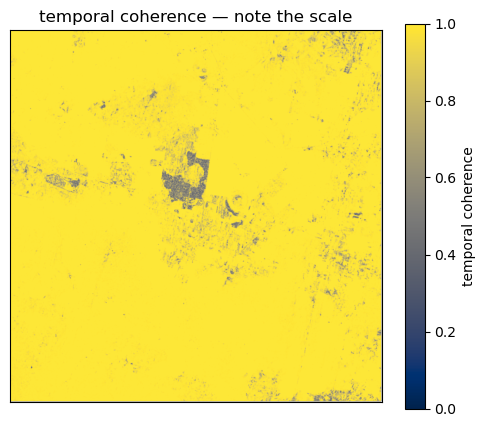

In [10]:
DOLPHIN = HERE / "mx_dolphin"
tcoh_path = next((DOLPHIN / "interferograms").glob("temporal_coherence_*.tif"))
tcoh = xr.open_dataarray(tcoh_path).squeeze()
tc = np.where(np.isfinite(tcoh.values), tcoh.values, np.nan)

for thresh in (0.5, 0.9, 0.99):
    print(
        f"fraction of pixels with temporal coherence > {thresh:.2f}: "
        f"{np.nanmean(tc > thresh):.3f}"
    )

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(tc, cmap="cividis", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="temporal coherence")
ax.set_title("temporal coherence — note the scale")
ax.set_xticks([]), ax.set_yticks([])
plt.show()

Almost the whole scene is above 0.99. This is because "temporal coherence" is another name for "phase linking misfit"; the fewer scenes you input, the less misfit possible.

See Figure 12 from Staniewicz, 2026:

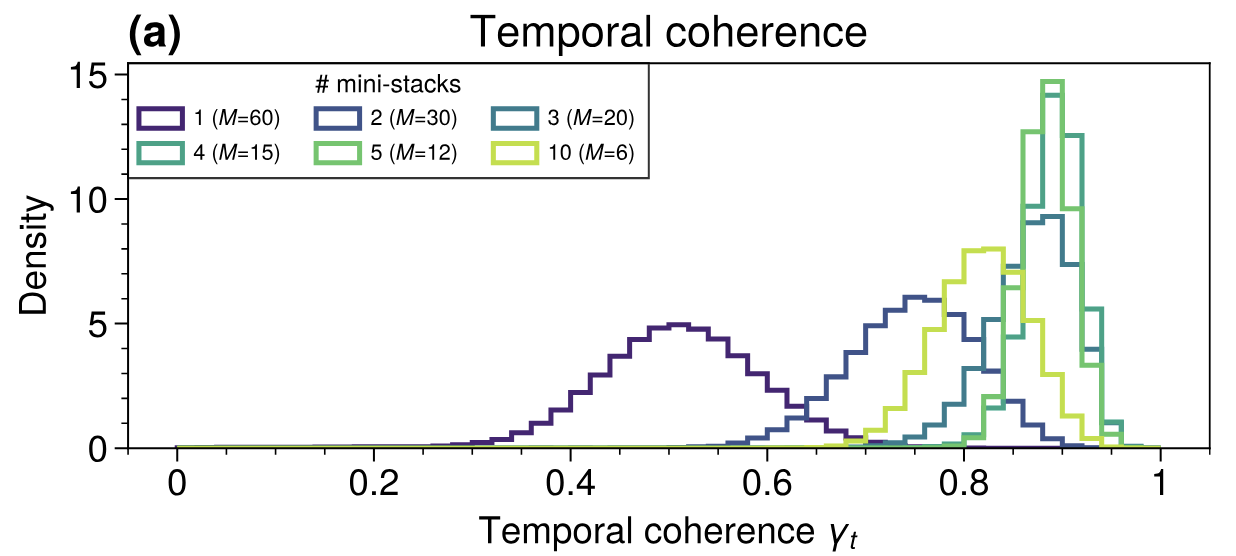

### Velocity

LOS velocity, cm/yr (negative = moving away = subsidence)
   p1 -10.0   median 15.2   p99 32.1


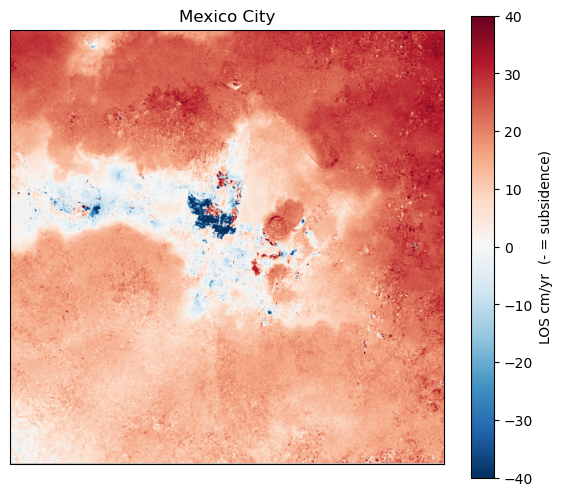

In [11]:
vel = xr.open_dataarray(DOLPHIN / "timeseries" / "velocity.tif").squeeze()
v_cm = vel.values * 100.0  # m/yr -> cm/yr
v_cm = np.where(np.isfinite(v_cm) & (v_cm != 0), v_cm, np.nan)

print("LOS velocity, cm/yr (negative = moving away = subsidence)")
print(
    "   p1 {:.1f}   median {:.1f}   p99 {:.1f}".format(
        *np.nanpercentile(v_cm, [1, 50, 99])
    )
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(v_cm, cmap="RdBu_r", vmin=-40, vmax=40)
plt.colorbar(im, ax=ax, label="LOS cm/yr  (- = subsidence)")
ax.set_title("Mexico City")
ax.set_xticks([]), ax.set_yticks([])
plt.show()

Note that the reference point chosen by dolphin is an arbitrary, high-coherence point in the middle of the largest connected component. No attempt is made to pick an area with zero deformation!

Re-referencing the velocity gives something more sensible:

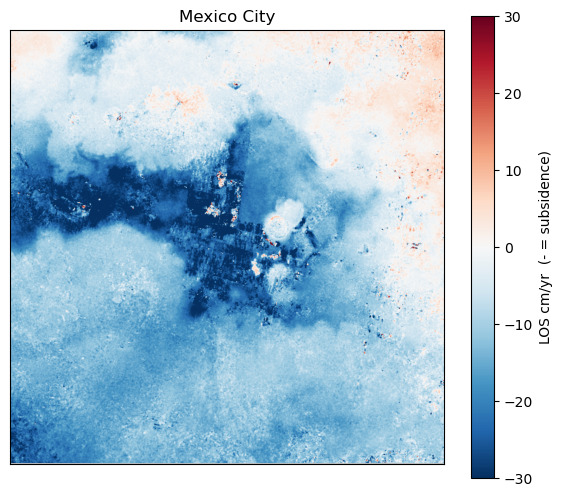

In [12]:
# Take the median of the top 3 rows as the average reference area
ref_value = np.nanmedian(v_cm[:3])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(v_cm - ref_value, cmap="RdBu_r", vmin=-30, vmax=30)
plt.colorbar(im, ax=ax, label="LOS cm/yr  (- = subsidence)")
ax.set_title("Mexico City")
ax.set_xticks([]), ax.set_yticks([])
plt.show()

### One pixel time series

The velocity above is a straight line fitted per pixel, but plotting the raw time series can show the nonlinearity of the subsidence

In [13]:
import re
import datetime 

import pandas as pd

def open_stack(filenames: list[Path | str]):
    """Open a stack of files as a single xarray dataset.
    Parameters
    ----------
    filenames : list[Filename]
        List of filenames to open.
    Returns
    -------
    xr.Dataset
        The dataset containing all files.
    """
    ds = xr.open_mfdataset(
        filenames,
        preprocess=_prep,
        engine="rasterio",
    )
    return ds


def _prep(ds):
    fname = ds.encoding["source"]
    date = get_dates(fname)[1]
    if len(ds.band) == 1:
        ds = ds.sel(band=ds.band[0])
    return ds.expand_dims(time=[pd.to_datetime(date)])


def get_dates(filename: Path | str, fmt: str = "%Y%m%d") -> list[datetime.date]:
    """Search for dates in the stem of `filename` matching `fmt`.
    Excludes dates that are not in the stem of `filename` (in the directories).
    """  # noqa: E501
    pattern = re.compile(r"\d{8}")
    date_list = re.findall(pattern, Path(filename).stem)
    if not date_list:
        return []
    return [_parse_date(d, fmt) for d in date_list]


def _parse_date(datestr: str, fmt: str = "%Y%m%d") -> datetime.date:
    return datetime.datetime.strptime(datestr, fmt).date()

In [14]:
ts_paths = sorted((DOLPHIN / "timeseries").glob("2*_2*.tif"))

ts_paths

[PosixPath('/home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/timeseries/20251025_20251106.tif'),
 PosixPath('/home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/timeseries/20251025_20251118.tif'),
 PosixPath('/home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/timeseries/20251025_20251130.tif'),
 PosixPath('/home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/timeseries/20251025_20251212.tif'),
 PosixPath('/home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/timeseries/20251025_20251224.tif'),
 PosixPath('/home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/timeseries/20251025_20260105.tif'),
 PosixPath('/home/jovyan/2026-isceplus/5.3_Intro_to_Dolphin/nisar-gslc/mx_dolphin/timeseries/20251025_20260117.tif')]

In [15]:
ds_ts = open_stack(ts_paths)
ds_ts

<xarray.Dataset> Size: 44MB
Dimensions:      (time: 7, y: 1249, x: 1249)
Coordinates:
  * time         (time) datetime64[ns] 56B 2025-11-06 2025-11-18 ... 2026-01-17
    band         int64 8B 1
  * x            (x) float64 10kB 4.907e+05 4.907e+05 ... 5.156e+05 5.156e+05
  * y            (y) float64 10kB 2.141e+06 2.141e+06 ... 2.116e+06 2.116e+06
    spatial_ref  int64 8B 0
Data variables:
    band_data    (time, y, x) float32 44MB dask.array<chunksize=(1, 256, 256), meta=np.ndarray>

In [16]:
%%time

ts_paths = sorted((DOLPHIN / "timeseries").glob("2*_2*.tif"))
ds_ts = open_stack(ts_paths)

# dolphin writes metres of LOS; cm reads better. Overwrite the units attribute
# that came off the GeoTIFF, or xarray will label the y-axis "meters".
ts = (ds_ts.band_data * 100).rename("los_cm")
ts.attrs["units"] = "cm"

# Fit a rate per pixel. `polyfit` works straight off the datetime64 coordinate,
# so the degree-1 coefficient comes back as cm per nanosecond.
NS_PER_YEAR = 365.25 * 24 * 3600 * 1e9
vel = (
    ts.polyfit("time", deg=1).polyfit_coefficients.sel(degree=1) * NS_PER_YEAR
).compute()

# But.. this will probably be noticeably slower than dolphin's (or MintPy's) more efficient inversion

CPU times: user 58.2 s, sys: 6.29 s, total: 1min 4s
Wall time: 58.3 s


In [17]:
# Sanity check: this should reproduce dolphin's own velocity.tif.
veldiff = (vel - v_cm)
print(f"RMS difference vs dolphin velocity.tif: {np.sqrt(np.mean(np.square(veldiff))).item():.4f} cm/yr")


RMS difference vs dolphin velocity.tif: 0.0013 cm/yr


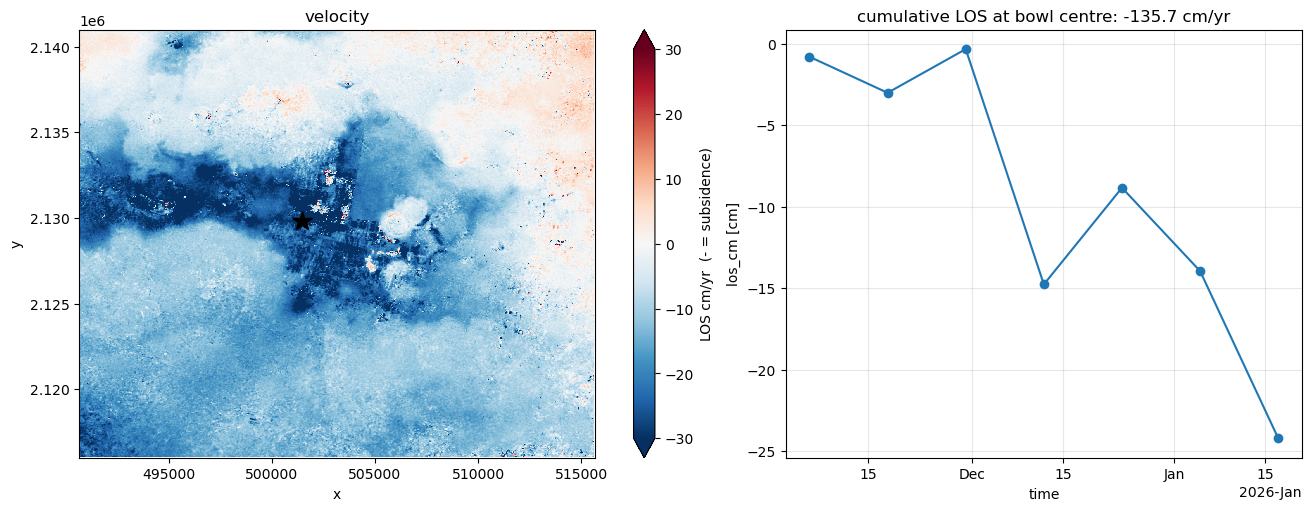

In [18]:
vel_referenced = vel - vel.isel(y=slice(0, 3)).median()

interior = vel_referenced.isel(x=slice(60, -60), y=slice(60, -60))
pt = interior.isel(interior.argmin(dim=["y", "x"]))
x0, y0 = float(pt.x), float(pt.y)

rate = float(vel_referenced.sel(x=x0, y=y0, method="nearest"))

series = ts.sel(x=x0, y=y0, method="nearest").compute()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
vel_referenced.plot.imshow(
    ax=axes[0], cmap="RdBu_r", vmin=-30, vmax=30,
    cbar_kwargs={"label": "LOS cm/yr  (- = subsidence)"},
)
axes[0].plot(x0, y0, "k*", ms=15)
axes[0].set_title("velocity")
series.plot.line("o-", ax=axes[1])
axes[1].set_title(f"cumulative LOS at bowl centre: {rate:.1f} cm/yr")
axes[1].grid(alpha=0.3)

## Homework

1. Re-run with `--interferogram-network.max-bandwidth 1` (nearest-neighbour only). Compare the velocity map. What do you notice about removing all redundancy from the inversion?
2. Mask the velocity with `similarity_*.tif` instead of temporal coherence. Does it separate good from bad ground better on a stack this short?
3. (optional) Pick a different NISAR frame and try it out yourself!